<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 2 - Random-dot motion: descriptive models</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h4>École Normale Supérieure</h4>
            <p> Valentin Wyart <br>
                Amric Trudel <br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Goals
In this TD, we will explore a descriptive model that is common for the random-dot motion task.


In [1]:
# TODO: add description of the task


We can derive a model with 3 parameters which can predict the reaction time and accuracy of participants depending of the level of motion coherence of the stimulus. The equations are shown in the figure below.

<img src="images/equations.png" style="height: 300px; margin-left: 10px;" />

The parameters are:
- A: the amplitude of the non-linearity
- k: the steepness of the non-linearity
- t_R: the residual time

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import ScalarFormatter
from pybads import BADS

from utils import generate_data, minimize

EPSILON = 1e-6

In [3]:
%reload_ext autoreload
%autoreload 2

## Random-dot motion


### Model

### Data Generation

We will generate behavioral data to work with.
We will pretend that we present a subject with stimuli that have 8 different levels of motion coherence, ranging between 0.1 and 100 on a log scale.
We will collect 100 trials for each level of motion coherence.

In [4]:
coherence_range = np.logspace(-1, 2, num=8, base=10)
coherence_range

array([  0.1       ,   0.26826958,   0.71968567,   1.93069773,
         5.17947468,  13.89495494,  37.2759372 , 100.        ])


Now, for each coherence rate, use the

In [5]:
data = generate_data(coherence_range, trials_per_coherence_rate=100)
data

,motion_coherence,reaction_time,outcome
0,0.1,603.506732,0
1,0.1,323.604726,1
2,0.1,513.898158,0
3,0.1,481.313212,0
4,0.1,325.873418,0
...,...,...,...
795,100.0,117.411755,1
796,100.0,160.513216,1
797,100.0,114.561865,1
798,100.0,185.662069,1



## Data Visualization

Now we will look at the data graphically. There are two things to plot: reaction times and accuracies. We will pack the plotting code in functions because we will need to reuse it.
#### a) Reaction times
Plot each trial as a separate point, with the motion coherence on the x axis, and the reaction time on the y axis.

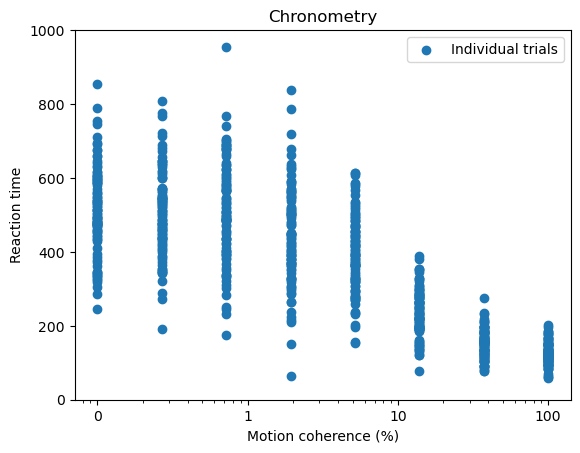

In [6]:
# Fill the missing code
def plot_reaction_time(data, model=None):
    ## Add your code here (ignore the 'model' argument for now)
    plt.scatter(data['motion_coherence'], data['reaction_time'], label='Individual trials')

    #########
    plt.title("Chronometry")
    plt.ylabel("Reaction time")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.ylim(0, 1000)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.legend()
    plt.show()


# Here we call the function on your dataset
plot_reaction_time(data)


### b) Accuracy
In this one, we won't plot each trial individually. Instead, we want to aggregate the outcomes of the trials corresponding to each motion coherence rate. In other words, your graph should display only 8 points, showing the accuracy of the participant for each coherence level.

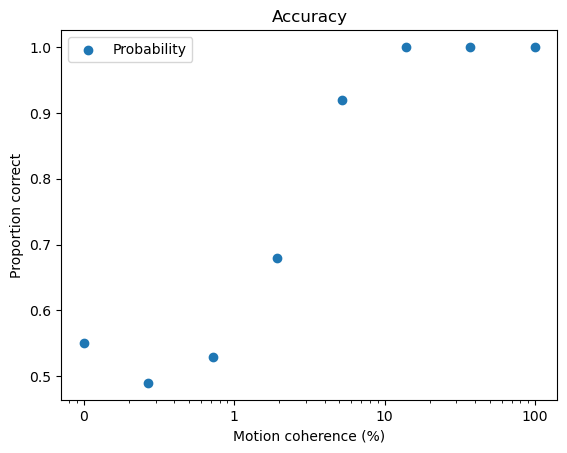

In [37]:
# Fill the missing code
def plot_accuracy(data, model=None):
    ## Add your code here
    accuracy = data.groupby('motion_coherence')['outcome'].mean()
    plt.scatter(accuracy.index, accuracy, label='Probability')

    ########
    plt.title("Accuracy")
    plt.ylabel("Proportion correct")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.legend()
    plt.show()

# We call the function on your dataset
plot_accuracy(data)

## Model
We will now define the model. The structure of the class is given to you, but you should implement the methods. Here are the equations again.
</br>
<img src="images/equations.png" style="height: 300px; margin-left: 10px;" />

In [8]:
class MotionCoherenceModel:
    def __init__(self, A, k, t_R):
        pass ## Your code here

    def predict_mean_reaction_time(self, x: np.ndarray) -> np.ndarray:
        pass ## Your code here

    def predict_accuracy(self, x: np.ndarray) -> np.ndarray:
        pass ## Your code here


In [41]:
# Solution

class MotionCoherenceModel:
    def __init__(self, A, k, t_R):
        self.A = A
        self.k = k
        self.t_R = t_R

    def predict_mean_reaction_time(self, x: float | np.ndarray) -> float | np.ndarray:
        t_T = self.A / (self.k * x) * np.tanh(self.A * self.k * x) + self.t_R
        return t_T

    def predict_accuracy(self, x: float | np.ndarray) -> float | np.ndarray:
        p_c = 1 / (1 + np.exp(-2 * self.A * self.k * np.abs(x)))
        return p_c


### Try your model
Now you can instantiate your MotionCoherenceModel class with parameter values of your choice and see what it outputs when you call the predict_** methods with the motion coherence rates that you use in your data.
Don't worry if you don't know what parameter values to give. Just try to guess for now.

In [9]:
test_model = MotionCoherenceModel(...)

TypeError: MotionCoherenceModel.__init__() missing 2 required positional arguments: 'k' and 't_R'

In [83]:
# Solution
test_model = MotionCoherenceModel(20, 0.01, 100)

Now, let's visualize your model's predictions on top of the graphs you generated previously. For this, edit your plotting functions that you wrote previously so that you can pass them your `test_model` as the last argument. You'll plot your model's predictions as a line on top of the scatter plot you already made for the raw data. For this, you can proceed in two ways, depending on your level coding proficiency.
- 💪 In the plotting function, you can simply call your model's predict_** method with the 8 different values of motion coherence that are in the data and make a line plot.
- 💪💪 You go a step further and generate a full range of about 1000 coherence motion values on a log scale between 0.01 and 100, and get your model's predictions on it. It will make a much smoother line to visualize your model's prediction.

Chronometry plot with the model's predictions


Accuracy plot with the model's predictions

Now play around a bit with your model's parameters and try to find values that can fit the data visually.

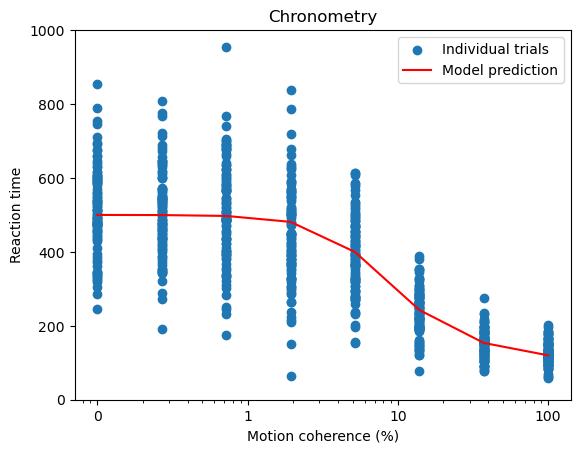

In [60]:
def plot_reaction_time(data, model=None):
    ## Add your code here (ignore the 'model' argument for now)
    plt.scatter(data['motion_coherence'], data['reaction_time'], label='Individual trials')
    pred = model.predict_mean_reaction_time(data['motion_coherence'])
    plt.plot(data['motion_coherence'], pred, label='Model prediction', c='red')
    #########
    plt.title("Chronometry")
    plt.ylabel("Reaction time")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.ylim(0, 1000)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.legend()
    plt.show()


plot_reaction_time(data, test_model)

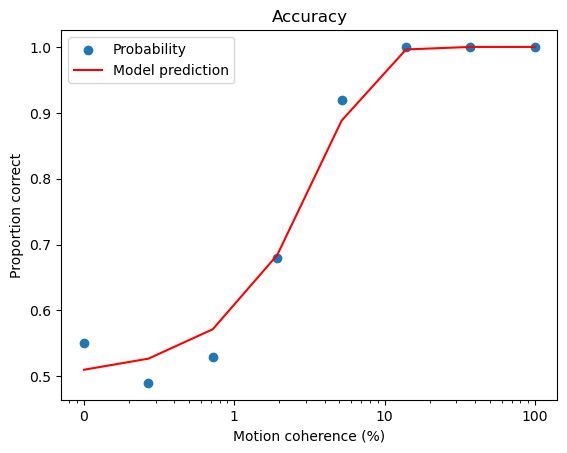

In [61]:
def plot_accuracy(data, model=None):
    ## Add your code here
    accuracy = data.groupby('motion_coherence')['outcome'].mean()
    plt.scatter(accuracy.index, accuracy, label='Probability')
    pred = model.predict_accuracy(data['motion_coherence'])
    plt.plot(data['motion_coherence'], pred, label='Model prediction', c='red')
    ########
    plt.title("Accuracy")
    plt.ylabel("Proportion correct")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.legend()
    plt.show()

# We call the function on your dataset
plot_accuracy(data, model=test_model)

## Model fitting
Now that we understand how the model parameters influence the model's predictions, we will now see how we can find the appropriate parameter values automatically through optimization.

Last time, the fitting code was all provided for you, but today we will start to dig into how it's done. For that, we need to know a bit more about parameter optimization. The method we will use requires us to define a **cost function**. This cost function must look at the model's outputs and evaluate how far they are from the actual values in the data.

Once we have defined the cost function, we can ask a standard optimization software to **minimize** it.

### Define a cost function
We will start by defining a cost function on the accuracy predictions (so we ignore the chronometry for now).
For this, we get:
- predictions: for any motion coherence value, the model can give the expected accuracy of the participants
- targets: we have data, so we can compute the accuracy of the subject on each. Actually, you have already computed the accuracy associated with each of the 8 levels of motion coherence when you made the s-shaped scatter plot. You will reuse them here as target values.

Fill the code below. The variables `prediction` and `targets` should hold an array of 8 values each.

As for how to compute the cost, I let you think about it a little bit before pointing you the usual metric that is used. How would you define the magnitude of your model's error *on each data point indiviudally*?

In [99]:
def accuracy_cost_function(parameters):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = ...

    # Generate accuracy predictions with a model that has the given parameter values
    predictions = ...

    # Extract the target values from the dataset
    targets = ...

    # Compute how far the predictions are from the targets
    cost = ...

    return cost

In [100]:
# Solution
def accuracy_cost_function(parameters):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = MotionCoherenceModel(A, k, t_R)

    # Generate predictions with a model that has the given parameter values
    predictions = candidate_model.predict_accuracy(coherence_range)

    # Extract the target values from the dataset
    targets = data.groupby('motion_coherence')['outcome'].mean().values

    # Compute how far the predictions are from the targets
    cost = np.sqrt(((targets - predictions) ** 2).mean())

    return cost

#### Test your cost function
Here are a few unit tests that you can run to check if your function works correctly

In [81]:
# TODO

### Fit your model!
Call the `minimize` function with the cost function you defined. There are extra steps hidden underneath this function because we have to define prior distributions for the parameters, but for today we will not worry about it and leave it for a future session!

In [104]:
params_optimized_for_accuracy = minimize(accuracy_cost_function)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2        0.026738               1                                 Uncertainty test
     0           6        0.026738               1         Initial mesh            Initial points
     0          10        0.026738             0.5         Refine grid             Train
     1          19        0.026738            0.25         Refine grid             Train
     2          22       0.0265929            0.25     Incremental search (ES-wcm)        
     2          29       0.0265929           0.125         Refine grid             Train
     3          30       0.0265754           0.125     Incremental search (ES-wcm)        
     3          39       0.0265754          0.0625         Refine grid             
     4          41       0.0265744          0.0

#### Visualize your optimized model's predictions

In [ ]:
model_optimized_for_accuracy = ...

In [106]:
model_optimized_for_accuracy = MotionCoherenceModel(**params_optimized_for_accuracy)

In [ ]:
# Plot the accuracy
...

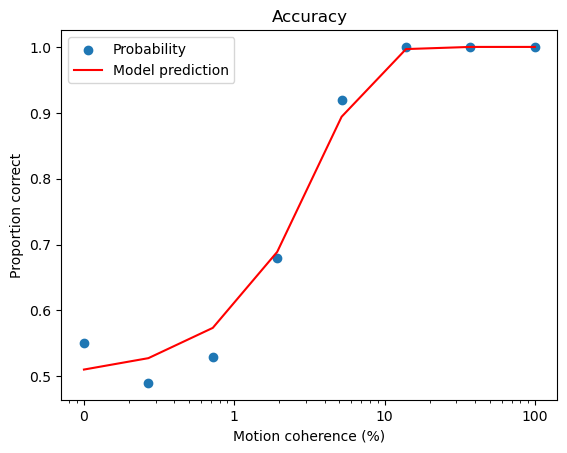

In [107]:
plot_accuracy(data, model_optimized_for_accuracy)

In [ ]:
# Plot the reaction time
...

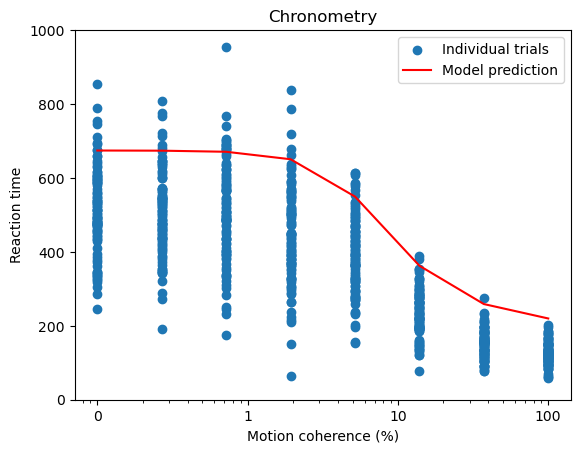

In [108]:
plot_reaction_time(data, model_optimized_for_accuracy)

## Write a different cost function
We can see that the model fits the accuracy data correctly, but not the chronometry. This is b
Furthermore, if you look at the equations again, you will see that there is a parameter that doesn't intervene in the accuracy prediction. This means that its value cannot be optimized with the cost function we wrote. Now, let's write a cost function that evaluates the error in the prediction of average response time.

In [ ]:
def chronometry_cost_function(parameters):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = ...

    # Generate average response time predictions with a model that has the given parameter values
    predictions = ...

    # Extract the target values from the dataset
    targets = ...

    # Compute how far the predictions are from the targets
    cost = ...

    return cost

In [131]:
# Solution
def rt_cost_function(parameters):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = MotionCoherenceModel(A, k, t_R)

    # Generate average response time predictions with a model that has the given parameter values
    predictions = candidate_model.predict_mean_reaction_time(coherence_range)

    # Extract the target values from the dataset
    targets = data.groupby('motion_coherence')['reaction_time'].mean().values

    # Compute how far the predictions are from the targets
    cost = np.sqrt(((predictions - targets) ** 2).mean())

    return cost

In [135]:
params_optimized_for_rt = minimize(rt_cost_function)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         15.1624               1                                 Uncertainty test
     0           6         15.1624               1         Initial mesh            Initial points
     0          10         15.1624             0.5         Refine grid             Train
     1          19         15.1624            0.25         Refine grid             Train
     2          29         15.1624           0.125         Refine grid             Train
     3          32         14.4688           0.125     Successful search (ES-ell)        
     3          33         14.3727           0.125     Successful search (ES-ell)        
     3          35         14.1702           0.125     Successful search (ES-ell)        
     3          37         14.1143         

### Visualize the predictions of a model optimized for the prediction of the average response time

In [ ]:
model_optimized_for_rt = ...

In [137]:
model_optimized_for_rt = MotionCoherenceModel(**params_optimized_for_rt)

In [ ]:
# Plot the reaction time
...

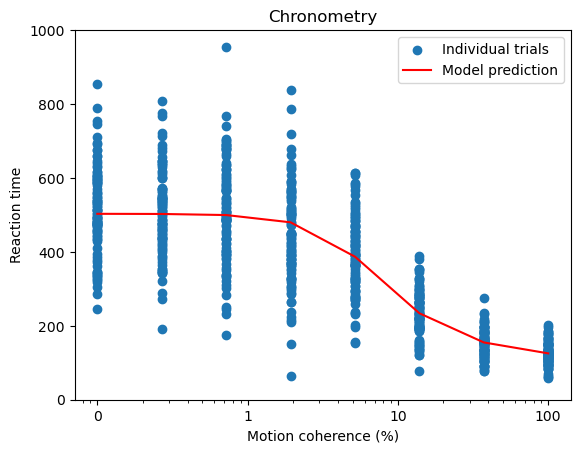

In [138]:
plot_reaction_time(data, model_optimized_for_rt)

In [ ]:
# Plot the accuracy
...

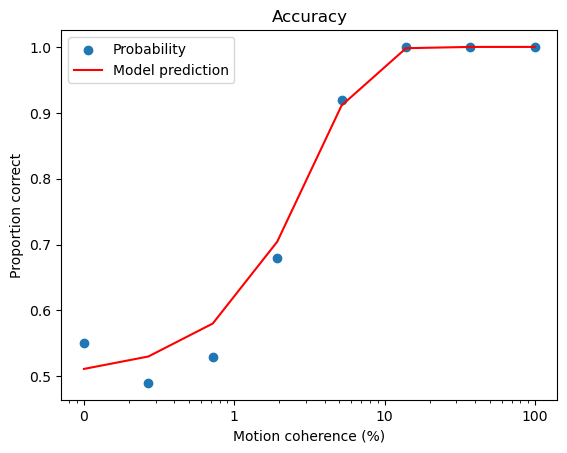

In [139]:

plot_accuracy(data, model_optimized_for_rt)

What predictions seem optimal?

You can check your optimized parameter values. If you look at the `utils.py` file, you'll find the original parameter values that were used to generate the data. See if the optimization got you close results.